<a href="https://colab.research.google.com/github/jnikem/pytorch-study/blob/main/sprint2_training_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import torch
import matplotlib.pyplot as plt

# 데이터: y = 3x + 2 를 따르는 점 4개
x = torch.tensor([1., 2., 3., 4.])
y = torch.tensor([5., 8., 11., 14.])

# 학습 대상: 아무 값에서 출발
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# 학습률: 한 걸음의 보폭
lr = 0.01

loss_hist, w_hist, b_hist = [], [], []

for epoch in range(1000):
    # ① 예측 (순전파)
    y_pred = w * x + b

    # ② 오차 (cost 함수 — 3B1B 2강의 그것)
    loss = ((y_pred - y) ** 2).mean()

    # ③ 미분 (역전파)
    loss.backward()

    # ④ 갱신 — 기울기 반대 방향으로 한 걸음
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    w.grad.zero_(); b.grad.zero_()

    loss_hist.append(loss.item())
    w_hist.append(w.item())
    b_hist.append(b.item())

print(f"시작 loss={loss_hist[0]:.2f} → 최종 loss={loss_hist[-1]:.6f}")
print(f"w={w.item():.3f}, b={b.item():.3f}")

시작 loss=101.50 → 최종 loss=0.000322
w=3.015, b=1.956


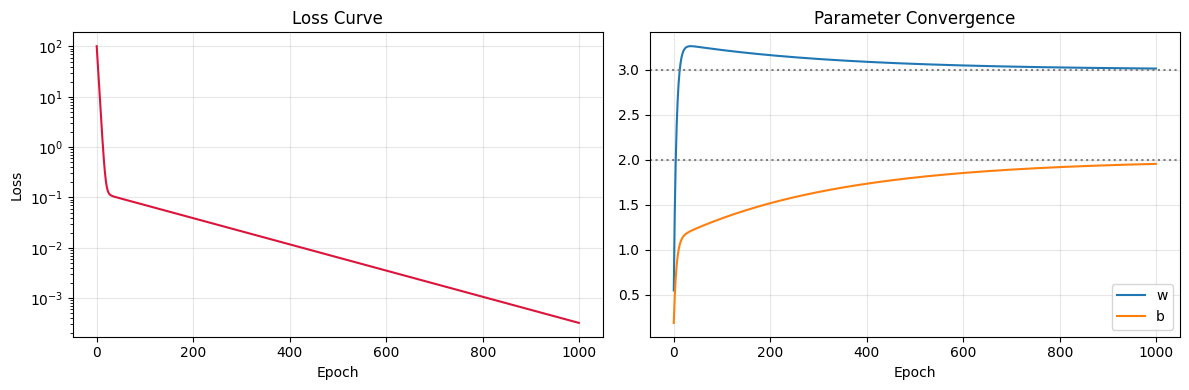

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(loss_hist, color='crimson')
ax[0].set_yscale('log')                      # 5자릿수 변화라 로그 스케일 필수
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].set_title('Loss Curve'); ax[0].grid(alpha=0.3)

ax[1].plot(w_hist, label='w')
ax[1].plot(b_hist, label='b')
ax[1].axhline(3.0, ls=':', c='gray'); ax[1].axhline(2.0, ls=':', c='gray')
ax[1].set_xlabel('Epoch'); ax[1].set_title('Parameter Convergence')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sprint2_curve.png', dpi=150, bbox_inches='tight')
plt.show()